In [1]:
# ==========================
# Data Handling
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================
# Data Preprocessing
# ==========================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# ==========================

# Model Evaluation
# =========================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

# metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
# ==========================
# Ignore Warnings
# ==========================
import warnings
warnings.filterwarnings("ignore")

In [2]:
values = pd.read_csv("train_values.csv")
labels = pd.read_csv("train_labels.csv")

In [3]:
df = pd.merge(values,labels, on = "building_id")

In [4]:
df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,n,r,...,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,...,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,...,0,0,0,0,0,0,0,0,0,2


In [5]:
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                               260601 non-null 

In [7]:
df.describe()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119,2.238272
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364,0.611814
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


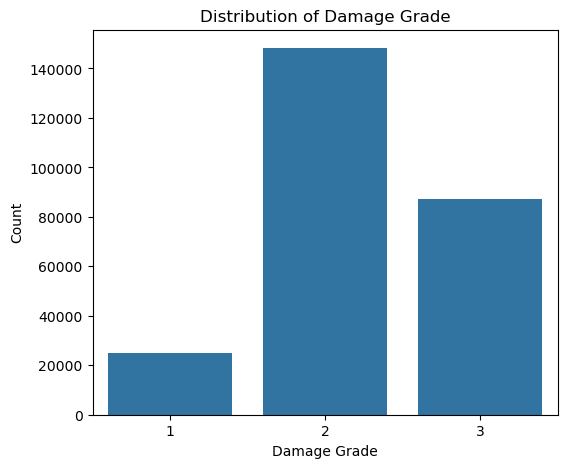

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data = df,
    x = "damage_grade"
)
plt.title("Distribution of Damage Grade")
plt.xlabel("Damage Grade")
plt.ylabel("Count")
plt.show()

In [9]:
df["damage_grade"].value_counts(normalize=True) * 100

damage_grade
2    56.891186
3    33.468022
1     9.640792
Name: proportion, dtype: float64

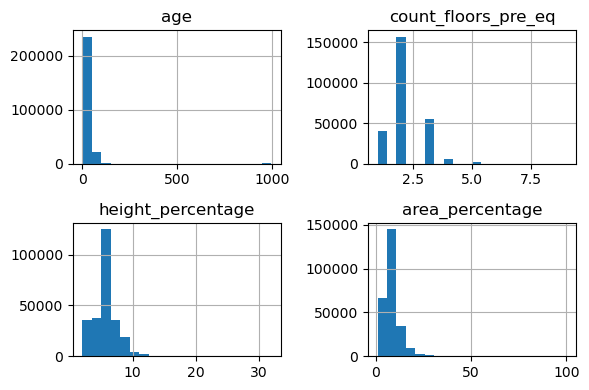

In [10]:
num_cols = [
    "age",
    "count_floors_pre_eq",
    "height_percentage",
    "area_percentage"
]

df[num_cols].hist(
    figsize=(6,4),
    bins=20
)

plt.tight_layout()
plt.show()

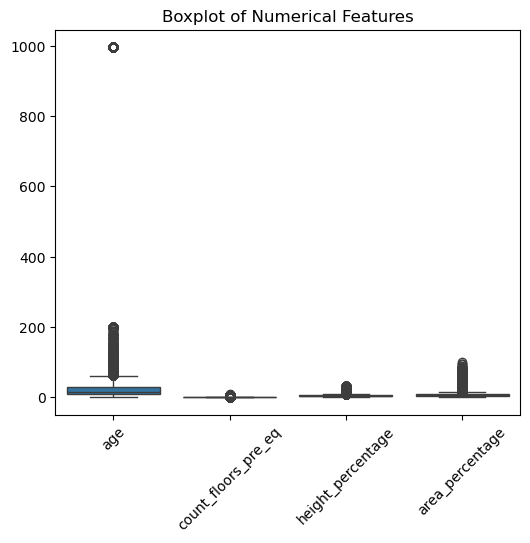

In [11]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df[
        [
            "age",
            "count_floors_pre_eq",
            "height_percentage",
            "area_percentage"
        ]
    ]
)

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

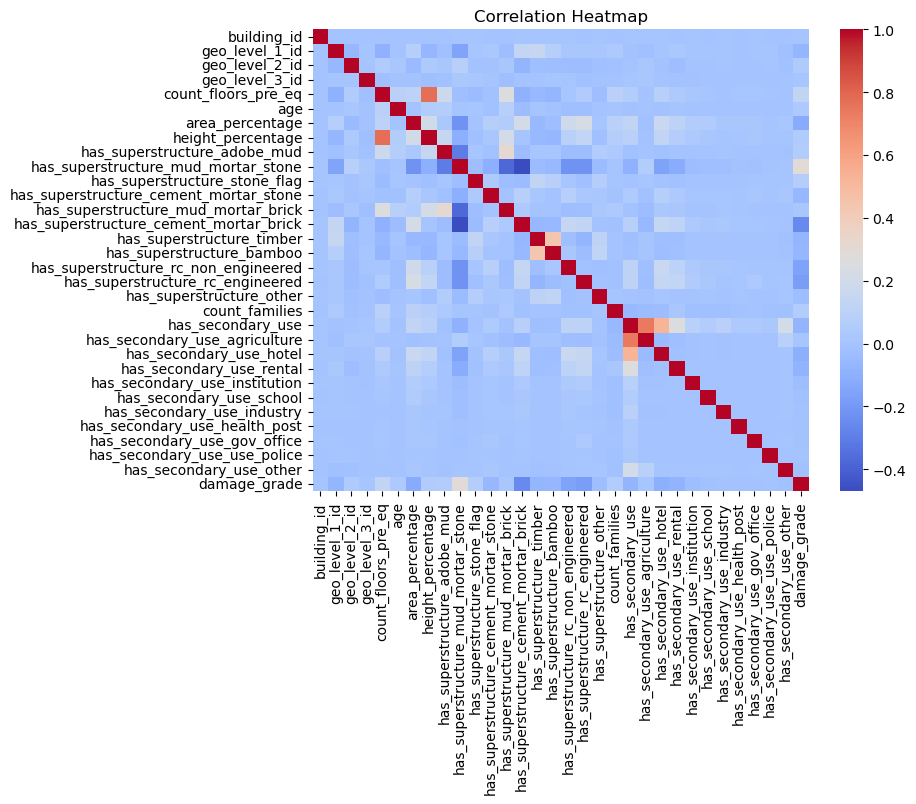

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

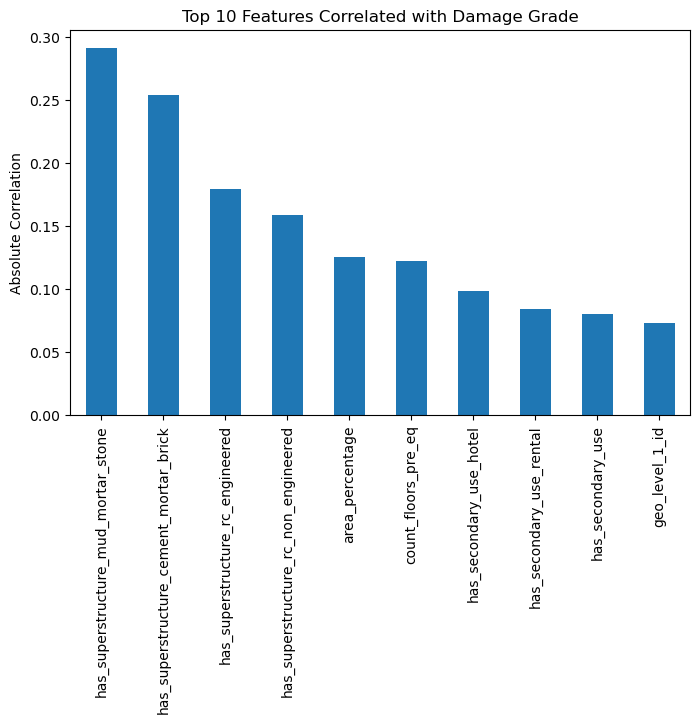

In [13]:
corr = df.corr(numeric_only=True)
top_corr = corr["damage_grade"].drop("damage_grade").abs().sort_values(ascending=False)

plt.figure(figsize=(8,5))

top_corr.head(10).plot(kind="bar")

plt.title("Top 10 Features Correlated with Damage Grade")
plt.ylabel("Absolute Correlation")

plt.show()

In [14]:
df.dtypes.value_counts()

int64     32
object     8
Name: count, dtype: int64

In [15]:
df.select_dtypes(include="object").columns

Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='object')

In [16]:

df = pd.get_dummies(
    df,
    drop_first=True,
    dtype=int
)

In [17]:
df.dtypes.value_counts()

int64    62
Name: count, dtype: int64

In [18]:
df

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,plan_configuration_f,plan_configuration_m,plan_configuration_n,plan_configuration_o,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w
0,802906,6,487,12198,2,30,6,5,1,1,...,0,0,0,0,0,0,0,0,1,0
1,28830,8,900,2812,2,10,8,7,0,1,...,0,0,0,0,0,0,0,0,1,0
2,94947,21,363,8973,2,10,5,5,0,1,...,0,0,0,0,0,0,0,0,1,0
3,590882,22,418,10694,2,10,6,5,0,1,...,0,0,0,0,0,0,0,0,1,0
4,201944,11,131,1488,3,30,8,9,1,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260596,688636,25,1335,1621,1,55,6,3,0,1,...,0,0,0,0,1,0,0,0,1,0
260597,669485,17,715,2060,2,0,6,5,0,1,...,0,0,0,0,0,0,0,0,1,0
260598,602512,17,51,8163,3,55,6,7,0,1,...,0,0,0,0,0,0,0,0,1,0
260599,151409,26,39,1851,2,10,14,6,0,0,...,0,0,0,0,0,0,0,0,1,0


In [19]:
X = df.drop("damage_grade",axis = 1)
y = df["damage_grade"]

In [20]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X_train)
Xt_Scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
Lo_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
Lo_model.fit(X_Scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
Lo_pred = Lo_model.predict(Xt_Scaled)
Lo_pred

array([2, 2, 2, ..., 2, 2, 2], shape=(52121,))

In [24]:
Lo_accuracy = accuracy_score(y_test, Lo_pred)
print("Accuracy :", Lo_accuracy)

Lo_precision = precision_score( y_test, Lo_pred, average="weighted")
print("Precision :", Lo_precision)

Lo_recall = recall_score( y_test, Lo_pred, average="weighted")
print("Recall :", Lo_recall)

Lo_f1 = f1_score(y_test, Lo_pred, average="weighted")
print("F1 Score :", Lo_f1)

Accuracy : 0.5882657661978857
Precision : 0.5758001138259928
Recall : 0.5882657661978857
F1 Score : 0.536266751258422


In [25]:
cr = classification_report(y_test, Lo_pred)
print("classification_report : ")
print(cr)

classification_report : 
              precision    recall  f1-score   support

           1       0.59      0.30      0.39      5170
           2       0.60      0.87      0.71     29487
           3       0.54      0.20      0.29     17464

    accuracy                           0.59     52121
   macro avg       0.57      0.45      0.46     52121
weighted avg       0.58      0.59      0.54     52121



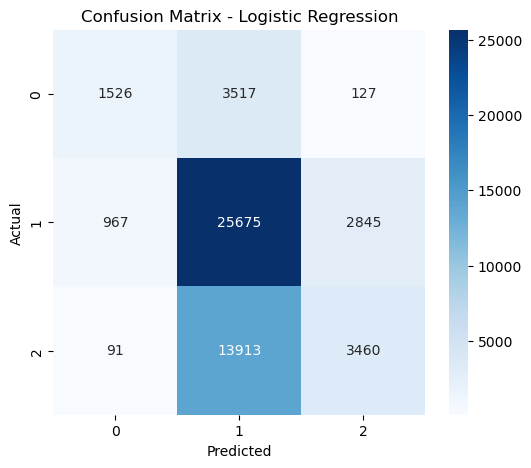

In [26]:
cm = confusion_matrix(y_test, Lo_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [27]:
from sklearn.tree import DecisionTreeClassifier
Dc_model = DecisionTreeClassifier(
    random_state=42
)
Dc_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
Dc_Pred = Dc_model.predict(X_test)
Dc_Pred


array([1, 2, 2, ..., 2, 3, 2], shape=(52121,))

In [30]:
Dc_accuracy = accuracy_score(y_test, Dc_Pred)
print("Accuracy :", Dc_accuracy)

Dc_precision = precision_score(y_test, Dc_Pred, average="weighted")
print("Precision :", Dc_precision)

Dc_recall = recall_score(y_test, Dc_Pred, average="weighted")
print("Recall :", Dc_recall)

Dc_f1 = f1_score(y_test, Dc_Pred, average="weighted")
print("F1 Score :", Dc_f1)

Accuracy : 0.6459008844803438
Precision : 0.6467786500214076
Recall : 0.6459008844803438
F1 Score : 0.6463071510517996


In [31]:
cr = classification_report(y_test, Dc_Pred)
print("Classification Report :")
print(cr)

Classification Report :
              precision    recall  f1-score   support

           1       0.49      0.49      0.49      5170
           2       0.70      0.69      0.70     29487
           3       0.60      0.61      0.61     17464

    accuracy                           0.65     52121
   macro avg       0.60      0.60      0.60     52121
weighted avg       0.65      0.65      0.65     52121



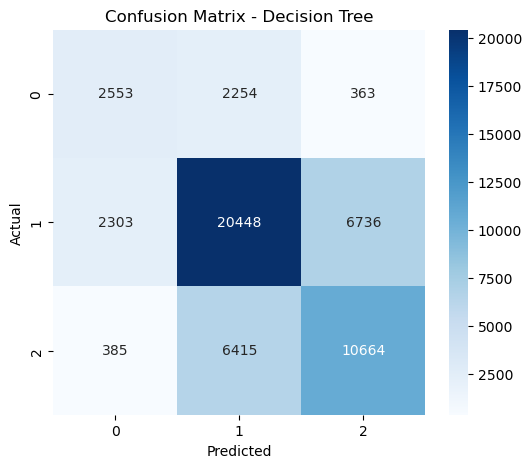

In [32]:
cm = confusion_matrix(y_test, Dc_Pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Decision Tree")

plt.show()